# Phase 1 — Baseline Experiments: Federated Medical Action Recognition

Compare **4 training strategies** on the same data and model:

| # | Method | Description |
|---|--------|-------------|
| 1 | **Centralized** | Train on all data combined (upper bound) |
| 2 | **FedAvg** | Standard federated averaging |
| 3 | **FedBN** | FedAvg but keep BatchNorm local |
| 4 | **Clustered FedBN** | FedBN + KMeans clustering of clients |

**Data:** 10 medical classes from NTU RGB+D 60, 5 clients, Dirichlet α=0.5
**Model:** STGCN++ (~443K params), COCO-17 skeleton
**Runtime:** T4 GPU recommended (~45 min total)

In [1]:
# @title Setup {display-mode: "form"}
!pip install -q scikit-learn

import os, time, copy, json, math, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter, defaultdict, OrderedDict

print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
assert torch.cuda.is_available(), "No GPU! Runtime → Change runtime type → T4 GPU"

PyTorch 2.10.0+cu128  |  CUDA: True
GPU: Tesla T4


In [2]:
# ═══ Configuration ═══
SEED = 42
NUM_CLASSES = 10
NUM_CLIENTS = 5
ALPHA = 0.5
BATCH_SIZE = 64
WARMUP_EPOCHS = 2
NUM_ROUNDS = 50
EPOCHS_PER_ROUND = 1
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
DEVICE = 'cuda'
NUM_CLUSTERS = 2
RECLUSTER_EVERY = 5
CENTRALIZED_EPOCHS = 20

MODEL_KWARGS = dict(base_channels=64, num_stages=6, num_person=2, dropout=0.3)

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.makedirs('outputs', exist_ok=True)
print('Config set ✓')

Config set ✓


## 1. Download NTU-60 Data & Filter Medical Subset

In [3]:
data_dir = 'data/nturgbd'
pkl_path = f'{data_dir}/ntu60_hrnet.pkl'

if not os.path.exists(pkl_path):
    os.makedirs(data_dir, exist_ok=True)
    !wget -q --show-progress -O {pkl_path} https://download.openmmlab.com/mmaction/pyskl/data/nturgbd/ntu60_hrnet.pkl
    print(f'Downloaded: {pkl_path}')
else:
    print(f'Already exists: {pkl_path}')

with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

split_info = data['split']
annotations = data['annotations']
print(f'Total NTU-60 annotations: {len(annotations)}')

# Medical-focused subset: NTU-60 indices → 10-class labels
MEDICAL_CLASS_MAP = {
    42: 0,  # falling
    41: 1,  # staggering
    43: 2,  # touch head (headache)
    44: 3,  # touch chest (heart pain)
    45: 4,  # touch back (backache)
    46: 5,  # touch neck (neckache)
    47: 6,  # nausea or vomiting
    8:  7,  # standing up
    7:  8,  # sitting down
    58: 9,  # walking towards each other
}

MEDICAL_LABELS = [
    'falling', 'staggering', 'touch head (headache)',
    'touch chest (heart pain)', 'touch back (backache)',
    'touch neck (neckache)', 'nausea or vomiting',
    'standing up', 'sitting down', 'walking towards',
]

selected_classes = set(MEDICAL_CLASS_MAP.keys())
medical_anns = [ann for ann in annotations if ann['label'] in selected_classes]
print(f'Filtered to {len(medical_anns)} medical samples ({NUM_CLASSES} classes)')

for orig_cls, new_cls in sorted(MEDICAL_CLASS_MAP.items(), key=lambda x: x[1]):
    count = sum(1 for a in medical_anns if a['label'] == orig_cls)
    tag = '🏥' if new_cls < 7 else '🟢'
    print(f'  {tag} [{new_cls}] {MEDICAL_LABELS[new_cls]:30s} ({count} samples)')

data/nturgbd/ntu60_ 100%[===================>] 672.72M  21.8MB/s    in 39s     
Downloaded: data/nturgbd/ntu60_hrnet.pkl
Total NTU-60 annotations: 56578
Filtered to 9444 medical samples (10 classes)
  🏥 [0] falling                        (946 samples)
  🏥 [1] staggering                     (947 samples)
  🏥 [2] touch head (headache)          (946 samples)
  🏥 [3] touch chest (heart pain)       (947 samples)
  🏥 [4] touch back (backache)          (948 samples)
  🏥 [5] touch neck (neckache)          (948 samples)
  🏥 [6] nausea or vomiting             (946 samples)
  🟢 [7] standing up                    (936 samples)
  🟢 [8] sitting down                   (941 samples)
  🟢 [9] walking towards                (939 samples)


## 2. Preprocessing

In [4]:
def prenormalize_2d(keypoint, keypoint_score, img_shape=(1080, 1920), threshold=0.01):
    kp = keypoint.astype(np.float32).copy()
    score = keypoint_score.astype(np.float32)
    kp = np.concatenate([kp, score[..., None]], axis=-1)
    mask_out = kp[..., 2] <= threshold
    h, w = img_shape
    kp[..., 0] = (kp[..., 0] - w / 2) / (w / 2)
    kp[..., 1] = (kp[..., 1] - h / 2) / (h / 2)
    kp[..., 0][mask_out] = 0
    kp[..., 1][mask_out] = 0
    return kp

def uniform_sample(keypoint, clip_len=100):
    M, T, V, C = keypoint.shape
    if T == clip_len:
        return keypoint
    inds = np.arange(clip_len) % T if T < clip_len else np.linspace(0, T - 1, clip_len, dtype=int)
    return keypoint[:, inds]

def format_gcn_input(keypoint, num_person=2):
    M, T, V, C = keypoint.shape
    if M < num_person:
        pad = np.zeros((num_person - M, T, V, C), dtype=keypoint.dtype)
        keypoint = np.concatenate([keypoint, pad], axis=0)
    return keypoint[:num_person]

def preprocess_sample(ann, clip_len=100, num_person=2):
    img_shape = ann.get('img_shape', (1080, 1920))
    kp = prenormalize_2d(ann['keypoint'], ann['keypoint_score'], img_shape)
    kp = uniform_sample(kp, clip_len)
    return format_gcn_input(kp, num_person)

test_out = preprocess_sample(medical_anns[0])
print(f'Sample shape: {test_out.shape}')

Sample shape: (2, 100, 17, 3)


## 3. Train/Test Split & Federated Partitioning

In [5]:
train_dirs = set(split_info['xsub_train'])
test_dirs = set(split_info['xsub_val'])

print('Preprocessing medical subset...')
t0 = time.time()

train_x, train_y, test_x, test_y = [], [], [], []
for ann in medical_anns:
    x = preprocess_sample(ann)
    new_label = MEDICAL_CLASS_MAP[ann['label']]
    if ann['frame_dir'] in train_dirs:
        train_x.append(x); train_y.append(new_label)
    elif ann['frame_dir'] in test_dirs:
        test_x.append(x); test_y.append(new_label)

train_x = np.stack(train_x).astype(np.float32)
train_y = np.array(train_y, dtype=np.int64)
test_x = np.stack(test_x).astype(np.float32)
test_y = np.array(test_y, dtype=np.int64)
print(f'Train: {train_x.shape}, Test: {test_x.shape} ({time.time()-t0:.1f}s)')

# Dirichlet non-IID split
rng = np.random.RandomState(SEED)
label_indices = defaultdict(list)
for i, label in enumerate(train_y):
    label_indices[int(label)].append(i)

client_indices = {i: [] for i in range(NUM_CLIENTS)}
for cls in range(NUM_CLASSES):
    idxs = np.array(label_indices[cls])
    rng.shuffle(idxs)
    proportions = rng.dirichlet([ALPHA] * NUM_CLIENTS)
    proportions = np.cumsum(proportions) / proportions.sum()
    splits = np.split(idxs, (proportions[:-1] * len(idxs)).astype(int))
    for cid, chunk in enumerate(splits):
        client_indices[cid].extend(chunk.tolist())

print(f'\nDirichlet split (α={ALPHA}):')
for cid in range(NUM_CLIENTS):
    ci = client_indices[cid]
    labels = train_y[ci]
    n_cls = len(set(labels))
    print(f'  Client {cid}: {len(ci):4d} samples, {n_cls}/{NUM_CLASSES} classes')

fed_dir = 'fed_data_medical'
os.makedirs(fed_dir, exist_ok=True)
for cid in range(NUM_CLIENTS):
    ci = np.array(client_indices[cid], dtype=int)
    np.savez_compressed(f'{fed_dir}/client_{cid}.npz', x=train_x[ci], y=train_y[ci])
np.savez_compressed(f'{fed_dir}/test.npz', x=test_x, y=test_y)
print(f'Saved to {fed_dir}/')

Preprocessing medical subset...
Train: (6695, 2, 100, 17, 3), Test: (2749, 2, 100, 17, 3) (1.4s)

Dirichlet split (α=0.5):
  Client 0: 1798 samples, 9/10 classes
  Client 1: 1078 samples, 10/10 classes
  Client 2: 1648 samples, 10/10 classes
  Client 3: 1253 samples, 10/10 classes
  Client 4:  918 samples, 10/10 classes
Saved to fed_data_medical/


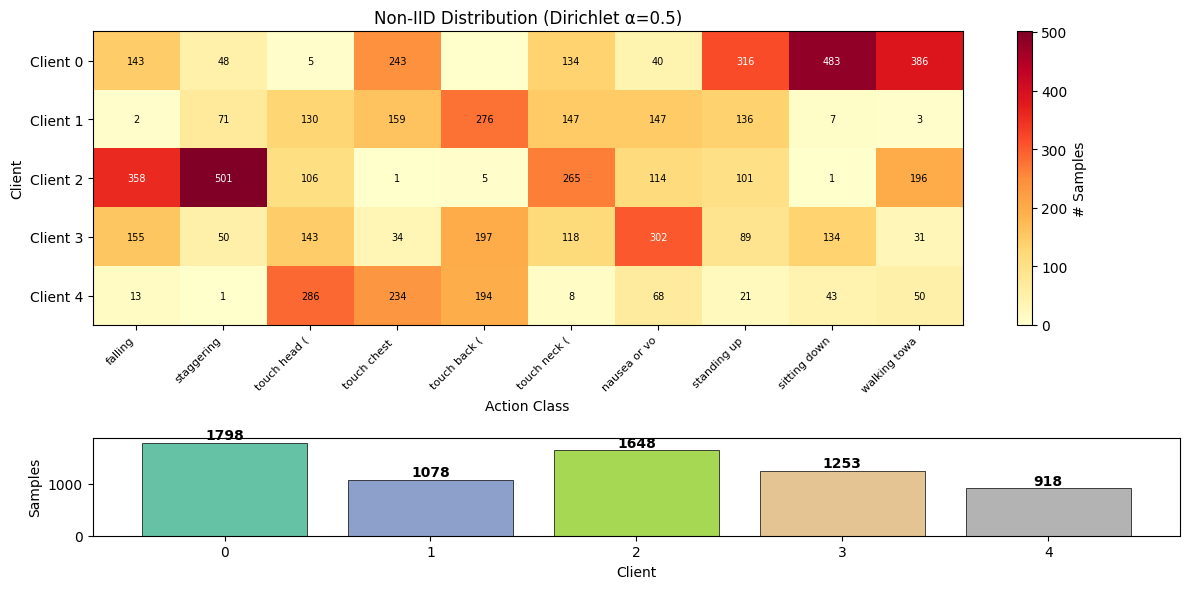

In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 10})

dist_matrix = np.zeros((NUM_CLIENTS, NUM_CLASSES), dtype=int)
for cid in range(NUM_CLIENTS):
    for idx in client_indices[cid]:
        dist_matrix[cid, int(train_y[idx])] += 1

fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [3, 1]})

im = axes[0].imshow(dist_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
axes[0].set_xlabel('Action Class')
axes[0].set_ylabel('Client')
axes[0].set_yticks(range(NUM_CLIENTS))
axes[0].set_yticklabels([f'Client {i}' for i in range(NUM_CLIENTS)])
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_xticklabels([l[:12] for l in MEDICAL_LABELS], rotation=45, ha='right', fontsize=8)
axes[0].set_title(f'Non-IID Distribution (Dirichlet α={ALPHA})')
plt.colorbar(im, ax=axes[0], label='# Samples')

for cid in range(NUM_CLIENTS):
    for cls in range(NUM_CLASSES):
        val = dist_matrix[cid, cls]
        if val > 0:
            axes[0].text(cls, cid, str(val), ha='center', va='center', fontsize=7,
                        color='white' if val > dist_matrix.max() * 0.6 else 'black')

client_totals = dist_matrix.sum(axis=1)
colors_bar = plt.cm.Set2(np.linspace(0, 1, NUM_CLIENTS))
bars = axes[1].bar(range(NUM_CLIENTS), client_totals, color=colors_bar, edgecolor='k', linewidth=0.5)
for bar, total in zip(bars, client_totals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{total}', ha='center', va='bottom', fontweight='bold')
axes[1].set_xlabel('Client')
axes[1].set_ylabel('Samples')
axes[1].set_xticks(range(NUM_CLIENTS))

plt.tight_layout()
plt.savefig('outputs/medical_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model Definition (STGCN++)

In [7]:
COCO_INWARD = [
    (15, 13), (13, 11), (16, 14), (14, 12),
    (11, 5), (12, 6), (9, 7), (7, 5), (10, 8), (8, 6),
    (5, 0), (6, 0), (1, 0), (3, 1), (2, 0), (4, 2),
]
COCO_NUM_JOINTS = 17
COCO_CENTER = 0

def _build_adjacency(num_node, edges, center):
    def _normalize(mx):
        d = mx.sum(axis=0); d[d == 0] = 1; return mx / d
    I = np.eye(num_node, dtype=np.float32)
    inward = np.zeros((num_node, num_node), dtype=np.float32)
    outward = np.zeros((num_node, num_node), dtype=np.float32)
    hop = np.full(num_node, 1e9, dtype=int); hop[center] = 0
    adj = {i: [] for i in range(num_node)}
    for u, v in edges:
        adj[u].append(v); adj[v].append(u)
    queue = [center]
    while queue:
        cur = queue.pop(0)
        for nb in adj[cur]:
            if hop[nb] > hop[cur] + 1:
                hop[nb] = hop[cur] + 1; queue.append(nb)
    for u, v in edges:
        if hop[u] < hop[v]:
            inward[v, u] = 1
        else:
            outward[u, v] = 1
    return np.stack([_normalize(I), _normalize(inward), _normalize(outward)])

def get_coco_adjacency():
    return _build_adjacency(COCO_NUM_JOINTS, COCO_INWARD, COCO_CENTER)


class MsTCN(nn.Module):
    def __init__(self, in_ch, out_ch, dilations=(1, 2, 3, 4), stride=1, dropout=0.0):
        super().__init__()
        mid = out_ch // (len(dilations) + 2)
        rem = out_ch - mid * (len(dilations) + 2)
        self.branches = nn.ModuleList()
        for d in dilations:
            self.branches.append(nn.Sequential(
                nn.Conv2d(in_ch, mid, 1), nn.BatchNorm2d(mid), nn.ReLU(True),
                nn.Conv2d(mid, mid, (3, 1), stride=(stride, 1), padding=(d, 0), dilation=(d, 1)),
                nn.BatchNorm2d(mid)))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_ch, mid, 1), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.MaxPool2d((3, 1), stride=(stride, 1), padding=(1, 0)), nn.BatchNorm2d(mid)))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_ch, mid + rem, 1), nn.BatchNorm2d(mid + rem)))
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        outs = [br(x) for br in self.branches]
        mt = min(o.size(2) for o in outs)
        return self.drop(torch.cat([o[:, :, :mt, :] for o in outs], dim=1))


class UnitGCN(nn.Module):
    def __init__(self, in_ch, out_ch, A, adaptive=True):
        super().__init__()
        K = A.size(0); self.K = K
        self.register_buffer('A', A)
        self.conv = nn.ModuleList([nn.Conv2d(in_ch, out_ch, 1) for _ in range(K)])
        self.PA = nn.Parameter(A.clone()) if adaptive else None
        self.bn = nn.BatchNorm2d(out_ch)
        self.res = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch)) if in_ch != out_ch else nn.Identity()
        for m in self.conv:
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        adj = self.A + self.PA if self.PA is not None else self.A
        out = sum(torch.einsum('nctv,vw->nctw', self.conv[k](x), adj[k]) for k in range(self.K))
        return F.relu(self.bn(out) + self.res(x), inplace=True)


class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, A, stride=1, dropout=0.0):
        super().__init__()
        self.gcn = UnitGCN(in_ch, out_ch, A)
        self.tcn = MsTCN(out_ch, out_ch, stride=stride, dropout=dropout)
        self.residual = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch),
            nn.AvgPool2d((stride, 1)) if stride > 1 else nn.Identity()
        ) if in_ch != out_ch or stride != 1 else nn.Identity()

    def forward(self, x):
        return F.relu(self.tcn(self.gcn(x)) + self.residual(x), inplace=True)


class STGCN(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, base_channels=64,
                 num_stages=6, inflate_stages=None, down_stages=None,
                 num_person=2, dropout=0.0):
        super().__init__()
        if inflate_stages is None:
            inflate_stages = [3, 5]
        if down_stages is None:
            down_stages = [3, 5]
        self.num_person = num_person
        A = torch.tensor(get_coco_adjacency(), dtype=torch.float32)
        self.data_bn = nn.BatchNorm1d(in_channels * COCO_NUM_JOINTS)
        channels = [base_channels]
        for i in range(1, num_stages):
            channels.append(channels[-1] * 2 if i in inflate_stages else channels[-1])
        self.blocks = nn.ModuleList()
        c_in = in_channels
        for i in range(num_stages):
            self.blocks.append(STGCNBlock(c_in, channels[i], A,
                               stride=2 if i in down_stages else 1, dropout=dropout))
            c_in = channels[i]
        self.out_channels = channels[-1]
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(self.out_channels, num_classes)
        nn.init.normal_(self.fc.weight, 0, math.sqrt(2.0 / num_classes))
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        N, M, T, V, C = x.shape
        x = x.permute(0, 1, 4, 2, 3).contiguous().view(N * M, C, T, V)
        x = x.permute(0, 1, 3, 2).contiguous().view(N * M, C * V, T)
        x = self.data_bn(x)
        x = x.view(N * M, C, V, T).permute(0, 1, 3, 2).contiguous()
        for block in self.blocks:
            x = block(x)
        x = self.pool(x).view(N, M, self.out_channels).mean(dim=1)
        return self.fc(self.drop(x))

def build_model(num_classes=10, in_channels=3, **kw):
    return STGCN(num_classes=num_classes, in_channels=in_channels, **kw)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_m = build_model(num_classes=NUM_CLASSES, dropout=0.3)
print(f'STGCN++ params: {count_parameters(_m):,}')
print(f'Output shape: {_m(torch.randn(2, 2, 100, 17, 3)).shape}')
del _m

STGCN++ params: 443,222
Output shape: torch.Size([2, 10])


## 5. Training Helpers

In [ ]:
def _is_bn_param(name):
    return 'bn' in name.lower() or 'data_bn' in name

def calibrate_bn(model, loader, device, max_batches=30):
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.reset_running_stats()
            m.momentum = None
    model.train()
    with torch.no_grad():
        for i, (xb, _) in enumerate(loader):
            if i >= max_batches:
                break
            model(xb.to(device))

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / max(total, 1)

def simple_kmeans(features, k=2, max_iter=50, seed=42):
    rng = np.random.RandomState(seed)
    n = len(features)
    centroids = features[rng.choice(n, k, replace=False)].copy()
    for _ in range(max_iter):
        dists = np.linalg.norm(features[:, None] - centroids[None], axis=2)
        labels = dists.argmin(axis=1)
        new_centroids = np.array([
            features[labels == j].mean(axis=0) if (labels == j).any() else centroids[j]
            for j in range(k)
        ])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels

def federated_aggregate(global_sd, client_weights, mode='fedavg', cluster_labels=None):
    all_keys = list(global_sd.keys())
    total_samples = sum(n for n, _ in client_weights)
    new_sd = OrderedDict()

    for k in all_keys:
        skip_bn = mode in ('fedbn', 'cluster_fedbn') and _is_bn_param(k)

        if skip_bn:
            new_sd[k] = global_sd[k].clone().float()
        elif mode == 'cluster_fedbn' and cluster_labels is not None:
            clusters = {}
            for cid, (n, sd) in enumerate(client_weights):
                cl = int(cluster_labels[cid])
                if cl not in clusters:
                    clusters[cl] = []
                clusters[cl].append((n, sd[k].float()))
            cluster_avgs = []
            for cl in sorted(clusters):
                t = sum(n for n, _ in clusters[cl])
                cluster_avgs.append(sum(n * v for n, v in clusters[cl]) / t)
            new_sd[k] = sum(cluster_avgs) / len(cluster_avgs)
        else:
            new_sd[k] = sum(n * sd[k].float() for n, sd in client_weights) / total_samples

    return new_sd

def run_fl_experiment(mode, warmstart_sd, client_loaders, calib_loader, test_loader):
    global_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **MODEL_KWARGS)
    global_model.load_state_dict(copy.deepcopy(warmstart_sd))

    history = []
    best_acc = 0.0
    best_sd = None
    cluster_labels = None
    device = torch.device(DEVICE)

    print(f'\n{"="*60}')
    print(f'{mode.upper()} — {NUM_ROUNDS} rounds, {NUM_CLIENTS} clients')
    print(f'{"="*60}')
    t0 = time.time()

    for rnd in range(1, NUM_ROUNDS + 1):
        cur_lr = LR
        if rnd > 35:
            cur_lr = LR * 0.01
        elif rnd > 20:
            cur_lr = LR * 0.1

        global_sd = copy.deepcopy(global_model.state_dict())
        client_weights = []
        client_accs = []

        for cid, loader in enumerate(client_loaders):
            local = build_model(num_classes=NUM_CLASSES, in_channels=3, **MODEL_KWARGS)
            local.load_state_dict(global_sd)
            local.to(device).train()
            opt = torch.optim.SGD(local.parameters(), lr=cur_lr,
                                  momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
            crit = nn.CrossEntropyLoss()

            correct, total = 0, 0
            for _ in range(EPOCHS_PER_ROUND):
                for xb, yb in loader:
                    xb, yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    logits = local(xb)
                    loss = crit(logits, yb)
                    loss.backward()
                    opt.step()
                    correct += (logits.argmax(1) == yb).sum().item()
                    total += yb.size(0)

            client_accs.append(correct / max(total, 1))
            client_weights.append((total, {k: v.cpu() for k, v in local.state_dict().items()}))
            del local
            torch.cuda.empty_cache()

        # Clustering (for cluster_fedbn)
        if mode == 'cluster_fedbn' and (rnd == 1 or rnd % RECLUSTER_EVERY == 0):
            descriptors = np.stack([sd['fc.weight'].numpy().flatten()
                                    for _, sd in client_weights])
            cluster_labels = simple_kmeans(descriptors, k=NUM_CLUSTERS)
            if rnd == 1 or rnd % 10 == 0:
                print(f'  Clusters (R{rnd}): {cluster_labels.tolist()}')

        # Aggregate
        new_sd = federated_aggregate(global_sd, client_weights, mode, cluster_labels)
        gsd = global_model.state_dict()
        for k in new_sd:
            gsd[k] = new_sd[k].to(gsd[k].dtype)
        global_model.load_state_dict(gsd)

        # BN calibration
        global_model.to(device)
        calibrate_bn(global_model, calib_loader, device)

        # Test
        test_acc = evaluate(global_model, test_loader, device)
        global_model.cpu()

        if test_acc > best_acc:
            best_acc = test_acc
            best_sd = copy.deepcopy(global_model.state_dict())

        history.append({
            'round': rnd, 'test_acc': float(test_acc),
            'mean_client_acc': float(np.mean(client_accs)),
            'worst_client_acc': float(np.min(client_accs)),
            'client_accs': [float(a) for a in client_accs],
        })

        if rnd % 10 == 0 or rnd == 1:
            print(f'  R{rnd:3d}/{NUM_ROUNDS}  test={test_acc:.4f}  '
                  f'mean={np.mean(client_accs):.4f}  worst={np.min(client_accs):.4f}')

    elapsed = time.time() - t0
    print(f'\n✓ {mode.upper()} done in {elapsed:.0f}s — Best: {best_acc:.4f}')
    return history, best_acc, best_sd

print('Helpers defined ✓')

Helpers defined ✓


## 6. Prepare Data Loaders

In [9]:
fed_dir = 'fed_data_medical'

client_loaders = []
all_x_parts, all_y_parts = [], []
for cid in range(NUM_CLIENTS):
    d = np.load(f'{fed_dir}/client_{cid}.npz')
    xc, yc = d['x'].astype(np.float32), d['y'].astype(np.int64)
    all_x_parts.append(xc)
    all_y_parts.append(yc)
    ds = TensorDataset(torch.from_numpy(xc), torch.from_numpy(yc))
    client_loaders.append(DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True))

all_train_x = np.concatenate(all_x_parts)
all_train_y = np.concatenate(all_y_parts)
all_train_loader = DataLoader(
    TensorDataset(torch.from_numpy(all_train_x), torch.from_numpy(all_train_y)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
calib_loader = DataLoader(
    TensorDataset(torch.from_numpy(all_train_x), torch.from_numpy(all_train_y)),
    batch_size=128, shuffle=True)

test_d = np.load(f'{fed_dir}/test.npz')
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(test_d['x'].astype(np.float32)),
                  torch.from_numpy(test_d['y'].astype(np.int64))),
    batch_size=128)

print(f'Train: {len(all_train_x)} samples ({NUM_CLIENTS} clients)')
print(f'Test:  {len(test_d["x"])} samples')
print('Loaders ready ✓')

Train: 6695 samples (5 clients)
Test:  2749 samples
Loaders ready ✓


## Experiment 1: Centralized Baseline (Upper Bound)

Train on **all combined data** — no federation.
This is the performance ceiling that FL methods try to approach.

In [10]:
print('Training centralized model (upper bound)...')
t0 = time.time()

cent_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **MODEL_KWARGS)
cent_model.to(DEVICE)
optimizer = torch.optim.SGD(cent_model.parameters(), lr=LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
criterion = nn.CrossEntropyLoss()

centralized_history = []
for epoch in range(1, CENTRALIZED_EPOCHS + 1):
    cent_model.train()
    correct, total, running_loss = 0, 0, 0.0
    for xb, yb in all_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = cent_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
        running_loss += loss.item() * yb.size(0)

    scheduler.step()
    test_acc = evaluate(cent_model, test_loader, DEVICE)
    centralized_history.append({
        'epoch': epoch, 'train_acc': correct / total,
        'test_acc': float(test_acc), 'loss': running_loss / total,
    })
    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:2d}/{CENTRALIZED_EPOCHS}  loss={running_loss/total:.4f}  '
              f'train={correct/total:.4f}  test={test_acc:.4f}')

centralized_best = max(h['test_acc'] for h in centralized_history)
centralized_final = centralized_history[-1]['test_acc']
elapsed = time.time() - t0
print(f'\n✓ Centralized done in {elapsed:.0f}s — Best: {centralized_best:.4f}')

torch.save(cent_model.cpu().state_dict(), 'outputs/baseline_centralized.pt')
with open('outputs/baseline_centralized.json', 'w') as f:
    json.dump({'history': centralized_history, 'best_acc': centralized_best}, f, indent=2)
del cent_model; torch.cuda.empty_cache()

Training centralized model (upper bound)...
  Epoch  1/20  loss=2.1744  train=0.2739  test=0.2896
  Epoch  5/20  loss=0.5472  train=0.7958  test=0.7897
  Epoch 10/20  loss=0.2708  train=0.9001  test=0.7574
  Epoch 15/20  loss=0.1813  train=0.9372  test=0.8618
  Epoch 20/20  loss=0.1655  train=0.9420  test=0.8807

✓ Centralized done in 1516s — Best: 0.8949


## Warm-Start for FL Methods (2 epochs)

All FL methods start from the same warm-start checkpoint for fair comparison.

In [11]:
print('Training warm-start model...')
t0 = time.time()

ws_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **MODEL_KWARGS)
ws_model.to(DEVICE)
optimizer = torch.optim.SGD(ws_model.parameters(), lr=LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, WARMUP_EPOCHS + 1):
    ws_model.train()
    correct, total = 0, 0
    for xb, yb in all_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = ws_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    test_acc = evaluate(ws_model, test_loader, DEVICE)
    print(f'  Epoch {epoch}/{WARMUP_EPOCHS}  train={correct/total:.4f}  test={test_acc:.4f}')

warmstart_sd = {k: v.cpu() for k, v in ws_model.state_dict().items()}
torch.save(warmstart_sd, 'outputs/baseline_warmstart.pt')
print(f'✓ Warm-start done in {time.time()-t0:.0f}s — Test: {test_acc:.4f}')
del ws_model; torch.cuda.empty_cache()

Training warm-start model...
  Epoch 1/2  train=0.2665  test=0.2757
  Epoch 2/2  train=0.3858  test=0.4874
✓ Warm-start done in 154s — Test: 0.4874


## Experiment 2: FedAvg (50 Rounds)

Standard federated averaging — **all parameters** (including BatchNorm) are aggregated.

In [12]:
fedavg_history, fedavg_best, fedavg_sd = run_fl_experiment(
    'fedavg', warmstart_sd, client_loaders, calib_loader, test_loader)

torch.save(fedavg_sd, 'outputs/baseline_fedavg.pt')
with open('outputs/baseline_fedavg.json', 'w') as f:
    json.dump({'history': fedavg_history, 'best_acc': fedavg_best}, f, indent=2)
print(f'Saved: outputs/baseline_fedavg.pt')


FEDAVG — 50 rounds, 5 clients
  R  1/50  test=0.4289  mean=0.5375  worst=0.3247
  R 10/50  test=0.6944  mean=0.6875  worst=0.5297
  R 20/50  test=0.7719  mean=0.7826  worst=0.6503
  R 30/50  test=0.7377  mean=0.7855  worst=0.6580
  R 40/50  test=0.7195  mean=0.7630  worst=0.5871
  R 50/50  test=0.7195  mean=0.7629  worst=0.5991

✓ FEDAVG done in 4551s — Best: 0.7719
Saved: outputs/baseline_fedavg.pt


## Experiment 3: FedBN (50 Rounds)

BatchNorm parameters **kept local** — only non-BN params aggregated.
Global model BN is re-calibrated after each round.

In [13]:
fedbn_history, fedbn_best, fedbn_sd = run_fl_experiment(
    'fedbn', warmstart_sd, client_loaders, calib_loader, test_loader)

torch.save(fedbn_sd, 'outputs/baseline_fedbn.pt')
with open('outputs/baseline_fedbn.json', 'w') as f:
    json.dump({'history': fedbn_history, 'best_acc': fedbn_best}, f, indent=2)
print(f'Saved: outputs/baseline_fedbn.pt')


FEDBN — 50 rounds, 5 clients
  R  1/50  test=0.4172  mean=0.5400  worst=0.3664
  R 10/50  test=0.6588  mean=0.6923  worst=0.5501
  R 20/50  test=0.7566  mean=0.7733  worst=0.6419
  R 30/50  test=0.7406  mean=0.7902  worst=0.6772
  R 40/50  test=0.7257  mean=0.7448  worst=0.5664
  R 50/50  test=0.7264  mean=0.7529  worst=0.5926

✓ FEDBN done in 4546s — Best: 0.7636
Saved: outputs/baseline_fedbn.pt


## Experiment 4: Clustered FedBN (50 Rounds)

FedBN + **KMeans clustering** — clients are grouped every 5 rounds based on
FC-layer weight similarity. Aggregation happens within clusters.

In [14]:
cluster_history, cluster_best, cluster_sd = run_fl_experiment(
    'cluster_fedbn', warmstart_sd, client_loaders, calib_loader, test_loader)

torch.save(cluster_sd, 'outputs/baseline_cluster.pt')
with open('outputs/baseline_cluster.json', 'w') as f:
    json.dump({'history': cluster_history, 'best_acc': cluster_best}, f, indent=2)
print(f'Saved: outputs/baseline_cluster.pt')


CLUSTER_FEDBN — 50 rounds, 5 clients
  Clusters (R1): [1, 0, 1, 0, 1]
  R  1/50  test=0.4420  mean=0.5431  worst=0.3414
  Clusters (R10): [0, 0, 0, 0, 1]
  R 10/50  test=0.5391  mean=0.6983  worst=0.5492
  Clusters (R20): [0, 0, 0, 0, 1]
  R 20/50  test=0.6333  mean=0.7600  worst=0.6224
  Clusters (R30): [0, 0, 0, 0, 1]
  R 30/50  test=0.7654  mean=0.7693  worst=0.6800
  Clusters (R40): [0, 0, 0, 0, 1]
  R 40/50  test=0.7461  mean=0.7369  worst=0.6327
  Clusters (R50): [0, 0, 0, 0, 1]
  R 50/50  test=0.7461  mean=0.7422  worst=0.6503

✓ CLUSTER_FEDBN done in 4550s — Best: 0.7683
Saved: outputs/baseline_cluster.pt


## 7. Comparison of All Methods

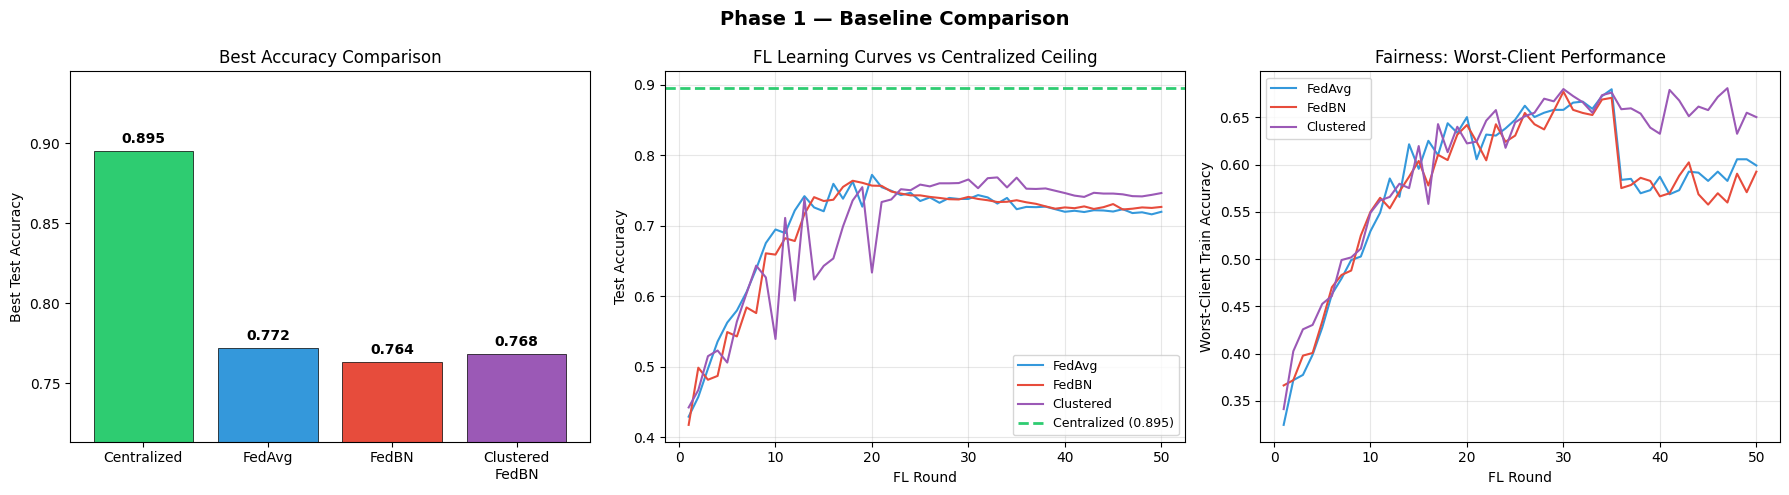


Method                 Best Acc  Final Acc  Gap vs Cent
-----------------------------------------------------------------
Centralized              0.8949     0.8807      +0.0000
FedAvg                   0.7719     0.7195      -0.1230
FedBN                    0.7636     0.7264      -0.1313
Clustered FedBN          0.7683     0.7461      -0.1266


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Bar chart of best accuracies
methods = ['Centralized', 'FedAvg', 'FedBN', 'Clustered\nFedBN']
best_accs = [centralized_best, fedavg_best, fedbn_best, cluster_best]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
bars = axes[0].bar(methods, best_accs, color=colors, edgecolor='k', linewidth=0.5)
axes[0].set_ylabel('Best Test Accuracy')
axes[0].set_title('Best Accuracy Comparison')
axes[0].set_ylim(min(best_accs) - 0.05, max(best_accs) + 0.05)
for bar, acc in zip(bars, best_accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', fontweight='bold', fontsize=10)

# Panel 2: FL learning curves
for name, hist, color in [('FedAvg', fedavg_history, '#3498db'),
                           ('FedBN', fedbn_history, '#e74c3c'),
                           ('Clustered', cluster_history, '#9b59b6')]:
    rounds = [h['round'] for h in hist]
    test_accs = [h['test_acc'] for h in hist]
    axes[1].plot(rounds, test_accs, '-', color=color, label=name, linewidth=1.5)
axes[1].axhline(y=centralized_best, color='#2ecc71', linestyle='--',
                label=f'Centralized ({centralized_best:.3f})', linewidth=2)
axes[1].set_xlabel('FL Round')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('FL Learning Curves vs Centralized Ceiling')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Panel 3: Fairness (worst-client accuracy)
for name, hist, color in [('FedAvg', fedavg_history, '#3498db'),
                           ('FedBN', fedbn_history, '#e74c3c'),
                           ('Clustered', cluster_history, '#9b59b6')]:
    rounds = [h['round'] for h in hist]
    worst = [h['worst_client_acc'] for h in hist]
    axes[2].plot(rounds, worst, '-', color=color, label=name, linewidth=1.5)
axes[2].set_xlabel('FL Round')
axes[2].set_ylabel('Worst-Client Train Accuracy')
axes[2].set_title('Fairness: Worst-Client Performance')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Phase 1 — Baseline Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f'\n{"="*65}')
print(f'{"Method":<20s} {"Best Acc":>10s} {"Final Acc":>10s} {"Gap vs Cent":>12s}')
print(f'{"-"*65}')
for name, best, hist in [
    ('Centralized', centralized_best, centralized_history),
    ('FedAvg', fedavg_best, fedavg_history),
    ('FedBN', fedbn_best, fedbn_history),
    ('Clustered FedBN', cluster_best, cluster_history),
]:
    final = hist[-1]['test_acc']
    gap = best - centralized_best
    print(f'{name:<20s} {best:>10.4f} {final:>10.4f} {gap:>+12.4f}')
print(f'{"="*65}')

In [16]:
phase1_results = {
    'config': {
        'seed': SEED, 'num_classes': NUM_CLASSES, 'num_clients': NUM_CLIENTS,
        'alpha': ALPHA, 'num_rounds': NUM_ROUNDS,
        'centralized_epochs': CENTRALIZED_EPOCHS,
        'warmup_epochs': WARMUP_EPOCHS, 'lr': LR, 'batch_size': BATCH_SIZE,
        'model_kwargs': {k: v for k, v in MODEL_KWARGS.items()},
    },
    'centralized': {
        'history': centralized_history,
        'best_acc': centralized_best,
        'final_acc': centralized_final,
    },
    'fedavg': {
        'history': fedavg_history,
        'best_acc': fedavg_best,
        'final_acc': fedavg_history[-1]['test_acc'],
    },
    'fedbn': {
        'history': fedbn_history,
        'best_acc': fedbn_best,
        'final_acc': fedbn_history[-1]['test_acc'],
    },
    'cluster_fedbn': {
        'history': cluster_history,
        'best_acc': cluster_best,
        'final_acc': cluster_history[-1]['test_acc'],
    },
}

with open('outputs/phase1_baselines.json', 'w') as f:
    json.dump(phase1_results, f, indent=2)

print('Saved: outputs/phase1_baselines.json')
print('\nPhase 1 complete! Upload outputs/phase1_baselines.json for analysis.')

# Copy to Drive (Colab)
try:
    import shutil
    from google.colab import drive
    drive.mount('/content/drive')
    dst = '/content/drive/MyDrive/demo1_baselines'
    os.makedirs(dst, exist_ok=True)
    for fn in ['outputs/phase1_baselines.json',
               'outputs/baseline_centralized.pt',
               'outputs/baseline_fedavg.pt',
               'outputs/baseline_fedbn.pt',
               'outputs/baseline_cluster.pt',
               'outputs/baseline_comparison.png']:
        if os.path.exists(fn):
            shutil.copy2(fn, dst)
    print(f'Copied to Drive: {dst}')
except Exception as e:
    print(f'Drive mount skipped ({e})')

Saved: outputs/phase1_baselines.json

Phase 1 complete! Upload outputs/phase1_baselines.json for analysis.
Drive mount skipped (mount failed)
